# Single SWV Trace Fit

This notebook shows the smallest ASWIFT workflow: load one voltage/current trace, run `aswift_fit` and `poly_linear_fit`, and plot the fitted peak and background profiles.

When public example data is available, set `DATA_URL` to a direct CSV download. Until then, the notebook falls back to a synthetic SWV-like trace.

In [1]:
from pathlib import Path
import sys
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Needed only when running from a source checkout instead of an installed package.
repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "src" / "aswift").exists():
        repo_root = candidate
        break
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from aswift import AswiftSettings, aswift_fit, poly_linear_fit
from aswift import plot_fit_result

## Load Example Data

Suggested public-data homes for later: GitHub Releases for small files, Zenodo/OSF/Figshare for citable datasets, or a simple static HTTPS URL if the files are small and stable.

In [2]:
DATA_URL = None  # example data, to be linked on Zenodo
DATA_PATH = Path("data/single_trace.csv")

if DATA_URL and not DATA_PATH.exists():
    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    volts = df["voltage"].to_numpy(dtype=float)
    current = df["current"].to_numpy(dtype=float)
else:
    # creates synthetic data if none provided
    volts = np.linspace(-0.4, 0, 400)
    background = 3.0 * (volts + 0.1)**2 + 1.0
    peak = 0.45 * np.exp(-0.5 * ((volts + 0.2) / 0.045) ** 2)
    noise = np.random.normal(loc=0, scale=0.01, size=len(volts))
    current = background + peak + noise

## Fit With ASWIFT and Poly-Linear

In [3]:
aswift_result = aswift_fit(volts, current)
poly_result = poly_linear_fit(volts, current)

pd.DataFrame([
    aswift_result.to_record(),
    poly_result.to_record(),
])[["method", "peak", "background", "peak_voltage", "success", "error"]]

,method,peak,background,peak_voltage,success,error
0,aswift,0.418088,1.059644,-0.199499,True,None
1,poly_linear,0.385058,1.095646,-0.202506,True,None


## Plot The Fits

`FitResult` stores full-length `peak_profile`, `background_profile`, and `fitted_current`, so plotting does not require reconstructing model coefficients.

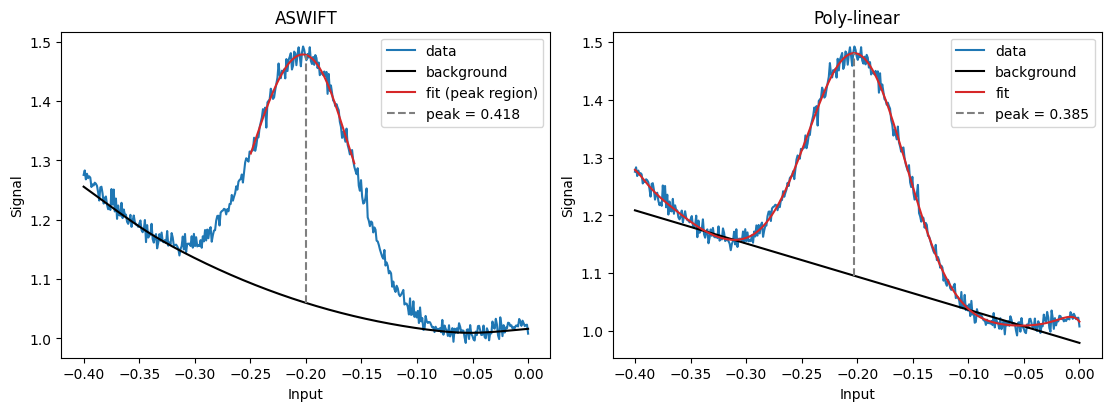

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_fit_result(aswift_result, ax=axes[0])
axes[0].set_title("ASWIFT")
plot_fit_result(poly_result, ax=axes[1])
axes[1].set_title("Poly-linear")
plt.show()

## Change ASWIFT Settings

ASWIFT defaults are chosen to work without manual tuning, but the settings object lets you inspect or deliberately change behavior. A common adjustment is `peak_prominence`, which controls how wide the prominence-based peak window is before local Tikhonov peak fitting. Larger values, such as `1.0`, use a wider peak region; smaller values focus the local fit more tightly around the peak.

Other settings:

- `baseline_boundary`: fraction of points protected at each edge when identifying the dominant peak window.
- `bg_buffer`: extra samples added to both sides of the detected peak window.
- `huber_reweight`: enables robust residual weighting during smoothing and peak fitting.
- `huber_cutoff`: scaled-residual cutoff for Huber-style downweighting; lower values downweight more aggressively.
- `mad_window`: rolling window used to estimate the local residual scale for robust weights.
- `peak_lambda_scale`: multiplier applied to the selected peak-smoothing lambda. Values below `1` allow a more flexible peak profile; values above `1` smooth more strongly.
- `peak_prominence`: relative-height threshold used to define the local peak window.


In [5]:
default_settings = AswiftSettings()
wide_peak_settings = AswiftSettings(peak_prominence=1.0)

default_aswift = aswift_fit(volts, current, settings=default_settings)
wide_peak_aswift = aswift_fit(volts, current, settings=wide_peak_settings)

pd.DataFrame([
    {"settings": "default", **default_aswift.to_record()},
    {"settings": "peak_prominence=1.0", **wide_peak_aswift.to_record()},
])[["settings", "peak", "background", "peak_voltage", "success", "error"]]


,settings,peak,background,peak_voltage,success,error
0,default,0.418088,1.059644,-0.199499,True,None
1,peak_prominence=1.0,0.417789,1.059644,-0.199499,True,None


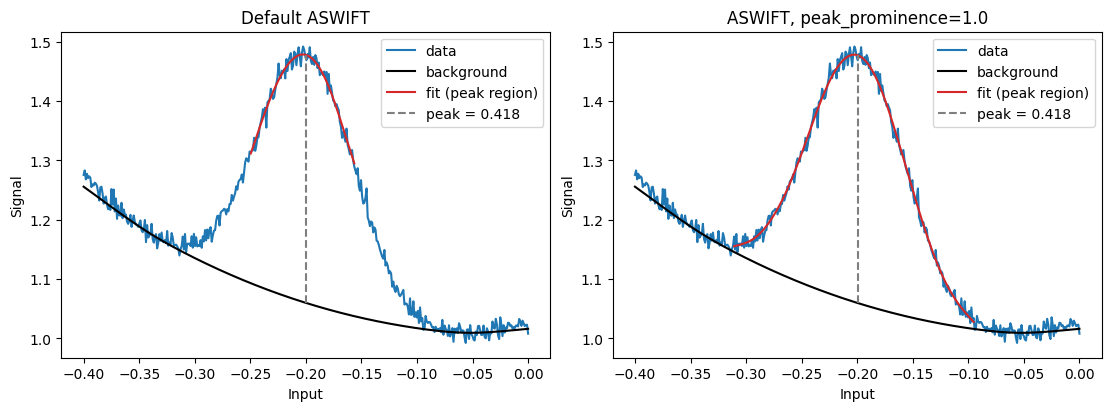

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
plot_fit_result(default_aswift, ax=axes[0])
axes[0].set_title("Default ASWIFT")
plot_fit_result(wide_peak_aswift, ax=axes[1])
axes[1].set_title("ASWIFT, peak_prominence=1.0")
plt.show()
